<a href="https://colab.research.google.com/github/karthik1338/geeksforgeeks/blob/main/day_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell imports necessary libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), accessing Kaggle datasets (kagglehub), building and training machine learning models (sklearn), and evaluating model performance. It also sets the plot style for visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Set plot style
sns.set_style('whitegrid')

This cell imports libraries specifically for building and working with deep learning models using Keras and TensorFlow, particularly for image processing tasks. It includes layers like Conv2D, MaxPooling2D, and Conv2DTranspose which are commonly used in image segmentation models like U-Net.

In [2]:
import os
import cv2 as cv
import numpy as np

import matplotlib.pyplot as plt

from keras.models import Model, load_model
from keras.layers import Input, BatchNormalization, Activation, Dense, Dropout, Conv2D, Conv2DTranspose, MaxPooling2D, GlobalMaxPool2D, concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
import tensorflow as tf

This cell was previously used to download a dataset using Kaggle Hub but is currently commented out.

In [3]:
# Download the dataset using the Kaggle Hub API
# print("Downloading dataset...")
# imgs = kagglehub.dataset_download("ashishjangra27/nifty-50-25-yrs-data")

# print("Path to dataset files:", imgs)

# # Load the dataset from the downloaded path
# # file_path = cv.imread(f'{path}/img_align_celeba')
# # df = pd.read_csv(file_path)

# # print("Dataset downloaded and loaded successfully.")
# # print(f"Data shape: {df.shape}")
# # df.head()

This cell defines the U-Net model architecture designed to take a 64x64 pixel input image and produce a 256x256 pixel output. It consists of an encoder path that downsamples the input and a decoder path that upsamples it, with skip connections between corresponding levels of the encoder and decoder.

In [4]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Activation, Dropout, Conv2DTranspose, concatenate
from tensorflow.keras.models import Model

def unet_64to256(input_shape=(64, 64, 3), n_classes=3, final_activation='sigmoid', dropout_rate=0.05):
    """
    U-Net model that takes a 64x64 input and produces a 256x256 output.
    The decoder includes two extra upsampling stages compared to a standard 64->64 U-Net.

    Args:
        input_shape (tuple): Shape of the input image (H, W, C). Defaults to (64, 64, 3).
        n_classes (int): Number of output classes (channels). Defaults to 3.
        final_activation (str): Activation function for the final output layer. Defaults to 'sigmoid'.
        dropout_rate (float): Dropout rate for regularization. Defaults to 0.05.

    Returns:
        tf.keras.Model: The constructed U-Net model.
    """
    inputs = Input(shape=input_shape, name='img')

    # =========================================================================
    # Encoder (64 -> 4) - Standard U-Net Downsampling
    # =========================================================================

    # 64 -> 32
    c1 = Conv2D(16, (3,3), padding='same')(inputs)
    c1 = BatchNormalization()(c1); c1 = Activation('relu')(c1)
    c1 = Conv2D(16, (3,3), padding='same')(c1)
    c1 = BatchNormalization()(c1); c1 = Activation('relu')(c1)
    p1 = MaxPooling2D((2,2))(c1); p1 = Dropout(dropout_rate)(p1)

    # 32 -> 16
    c2 = Conv2D(32, (3,3), padding='same')(p1)
    c2 = BatchNormalization()(c2); c2 = Activation('relu')(c2)
    c2 = Conv2D(32, (3,3), padding='same')(c2)
    c2 = BatchNormalization()(c2); c2 = Activation('relu')(c2)
    p2 = MaxPooling2D((2,2))(c2); p2 = Dropout(dropout_rate)(p2)

    # 16 -> 8
    c3 = Conv2D(64, (3,3), padding='same')(p2)
    c3 = BatchNormalization()(c3); c3 = Activation('relu')(c3)
    c3 = Conv2D(64, (3,3), padding='same')(c3)
    c3 = BatchNormalization()(c3); c3 = Activation('relu')(c3)
    p3 = MaxPooling2D((2,2))(c3); p3 = Dropout(dropout_rate)(p3)

    # 8 -> 4
    c4 = Conv2D(128, (3,3), padding='same')(p3)
    c4 = BatchNormalization()(c4); c4 = Activation('relu')(c4)
    c4 = Conv2D(128, (3,3), padding='same')(c4)
    c4 = BatchNormalization()(c4); c4 = Activation('relu')(c4)
    p4 = MaxPooling2D((2,2))(c4); p4 = Dropout(dropout_rate)(p4)

    # Bottleneck (4x4)
    c5 = Conv2D(256, (3,3), padding='same')(p4)
    c5 = BatchNormalization()(c5); c5 = Activation('relu')(c5)
    c5 = Conv2D(256, (3,3), padding='same')(c5)
    c5 = BatchNormalization()(c5); c5 = Activation('relu')(c5)

    # =========================================================================
    # Decoder (4 -> 256) - Upsampling to final size
    # =========================================================================

    # 4 -> 8 (Skip connection from c4)
    u6 = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c4]); u6 = Dropout(dropout_rate)(u6)
    u6 = Conv2D(128, (3,3), padding='same')(u6)
    u6 = BatchNormalization()(u6); u6 = Activation('relu')(u6)
    u6 = Conv2D(128, (3,3), padding='same')(u6)
    u6 = BatchNormalization()(u6); u6 = Activation('relu')(u6)

    # 8 -> 16 (Skip connection from c3)
    u7 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same')(u6)
    u7 = concatenate([u7, c3]); u7 = Dropout(dropout_rate)(u7)
    u7 = Conv2D(64, (3,3), padding='same')(u7)
    u7 = BatchNormalization()(u7); u7 = Activation('relu')(u7)
    u7 = Conv2D(64, (3,3), padding='same')(u7)
    u7 = BatchNormalization()(u7); u7 = Activation('relu')(u7)

    # 16 -> 32 (Skip connection from c2)
    u8 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same')(u7)
    u8 = concatenate([u8, c2]); u8 = Dropout(dropout_rate)(u8)
    u8 = Conv2D(32, (3,3), padding='same')(u8)
    u8 = BatchNormalization()(u8); u8 = Activation('relu')(u8)
    u8 = Conv2D(32, (3,3), padding='same')(u8)
    u8 = BatchNormalization()(u8); u8 = Activation('relu')(u8)

    # 32 -> 64 (Skip connection from c1)
    u9 = Conv2DTranspose(16, (3,3), strides=(2,2), padding='same')(u8)
    u9 = concatenate([u9, c1]); u9 = Dropout(dropout_rate)(u9)
    u9 = Conv2D(16, (3,3), padding='same')(u9)
    u9 = BatchNormalization()(u9); u9 = Activation('relu')(u9)
    u9 = Conv2D(16, (3,3), padding='same')(u9)
    u9 = BatchNormalization()(u9); u9 = Activation('relu')(u9)

    # Extra upsample 1: 64 -> 128 (No skip connection available at this resolution)
    u10 = Conv2DTranspose(16, (3,3), strides=(2,2), padding='same')(u9)
    u10 = Dropout(dropout_rate)(u10)
    u10 = Conv2D(16, (3,3), padding='same')(u10)
    u10 = BatchNormalization()(u10); u10 = Activation('relu')(u10)
    u10 = Conv2D(16, (3,3), padding='same')(u10)
    u10 = BatchNormalization()(u10); u10 = Activation('relu')(u10)

    # Extra upsample 2: 128 -> 256 (No skip connection available at this resolution)
    u11 = Conv2DTranspose(16, (3,3), strides=(2,2), padding='same')(u10) # 128 -> 256
    u11 = Dropout(dropout_rate)(u11)
    u11 = Conv2D(16, (3,3), padding='same')(u11)
    u11 = BatchNormalization()(u11); u11 = Activation('relu')(u11)
    u11 = Conv2D(16, (3,3), padding='same')(u11)
    u11 = BatchNormalization()(u11); u11 = Activation('relu')(u11)

    # Final output layer
    outputs = Conv2D(n_classes, (1,1), activation=final_activation, name='mask')(u11)

    return Model(inputs=inputs, outputs=outputs, name='UNet_64to256')

# Example of how to use the model:
# from tensorflow.keras.utils import plot_model
# model = unet_64to256()
# model.summary()
# plot_model(model, to_file='unet_64to256.png', show_shapes=True)

This cell initializes the U-Net model with a specified input shape, number of output classes, and final activation function. It then compiles the model using the Adam optimizer and Mean Absolute Error (MAE) as the loss function. It also prints the input and output shapes of the compiled model.

In [5]:
model = unet_64to256(input_shape=(64,64,3), n_classes=3, final_activation='sigmoid')

print('Input shape:', model.input_shape)   # (None, 64, 64, 3)
print('Output shape:', model.output_shape) # (None, 256, 256, 3)

model.compile(optimizer=Adam(1e-4), loss='mae' )

Input shape: (None, 64, 64, 3)
Output shape: (None, 256, 256, 3)


This cell downloads the CelebA dataset using the Kaggle Hub API and stores the path to the dataset in the `path` variable.

In [6]:
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

Using Colab cache for faster access to the 'celeba-dataset' dataset.


This cell defines a Python generator function `datagen` that yields batches of input images (resized to 64x64) and their corresponding target images (resized to 256x256) for training the U-Net model. It reads images from the specified directory, resizes them, and performs basic preprocessing (scaling pixel values to the range [0, 1]).

In [7]:
import os
import cv2 as cv
import numpy as np

# Use the path variable from the kagglehub download
img_dir = os.path.join(path, 'img_align_celeba', 'img_align_celeba')
imgs = os.listdir(img_dir)


def datagen(batch_size):

    while True:
        x_batch = []
        y_batch = []

        for _ in range(batch_size):
            indx = np.random.randint(0, len(imgs))

            # Use the correct path to read the image
            bgr = cv.imread(os.path.join(img_dir, imgs[indx]))
            bgr = cv.resize(bgr, (256, 256))
            rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

            # blur = cv.blur(rgb, (4, 4))

            x = cv.resize(rgb, (64, 64))
            x = x / 255.0
            y = rgb / 255.0

            x_batch.append(x)
            y_batch.append(y)

        x_batch = np.array(x_batch).reshape(batch_size, 64, 64, 3)
        y_batch = np.array(y_batch).reshape(batch_size, 256, 256, 3)

        yield x_batch, y_batch

This cell prepares for model training by setting the batch size and calculating the number of steps per epoch based on the total number of images. It then starts the model training process using the `fit` method, providing the data generator, steps per epoch, and the number of training epochs.

In [8]:
batch_size = 32

num_images = len(imgs)
steps_per_epoch = num_images // batch_size


results = model.fit(datagen(batch_size=batch_size), steps_per_epoch=steps_per_epoch , epochs=5, verbose=1)

Epoch 1/5
6331/6331 ━━━━━━━━━━━━━━━━━━━━ 1550s 238ms/step - loss: 0.0603
Epoch 2/5
6331/6331 ━━━━━━━━━━━━━━━━━━━━ 1149s 181ms/step - loss: 0.0314
Epoch 3/5
6331/6331 ━━━━━━━━━━━━━━━━━━━━ 1035s 163ms/step - loss: 0.0276
Epoch 4/5
6331/6331 ━━━━━━━━━━━━━━━━━━━━ 1015s 160ms/step - loss: 0.0253
Epoch 5/5
6331/6331 ━━━━━━━━━━━━━━━━━━━━ 1019s 161ms/step - loss: 0.0239


This cell defines a function `show_and_save_samples` to visualize model predictions during training and a Keras callback `show_cb` that calls this function at the end of each epoch. It also sets up the necessary directories for saving checkpoints and then initiates the model training process using the data generator, steps per epoch, and the defined callback.

6331/6331 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.0231

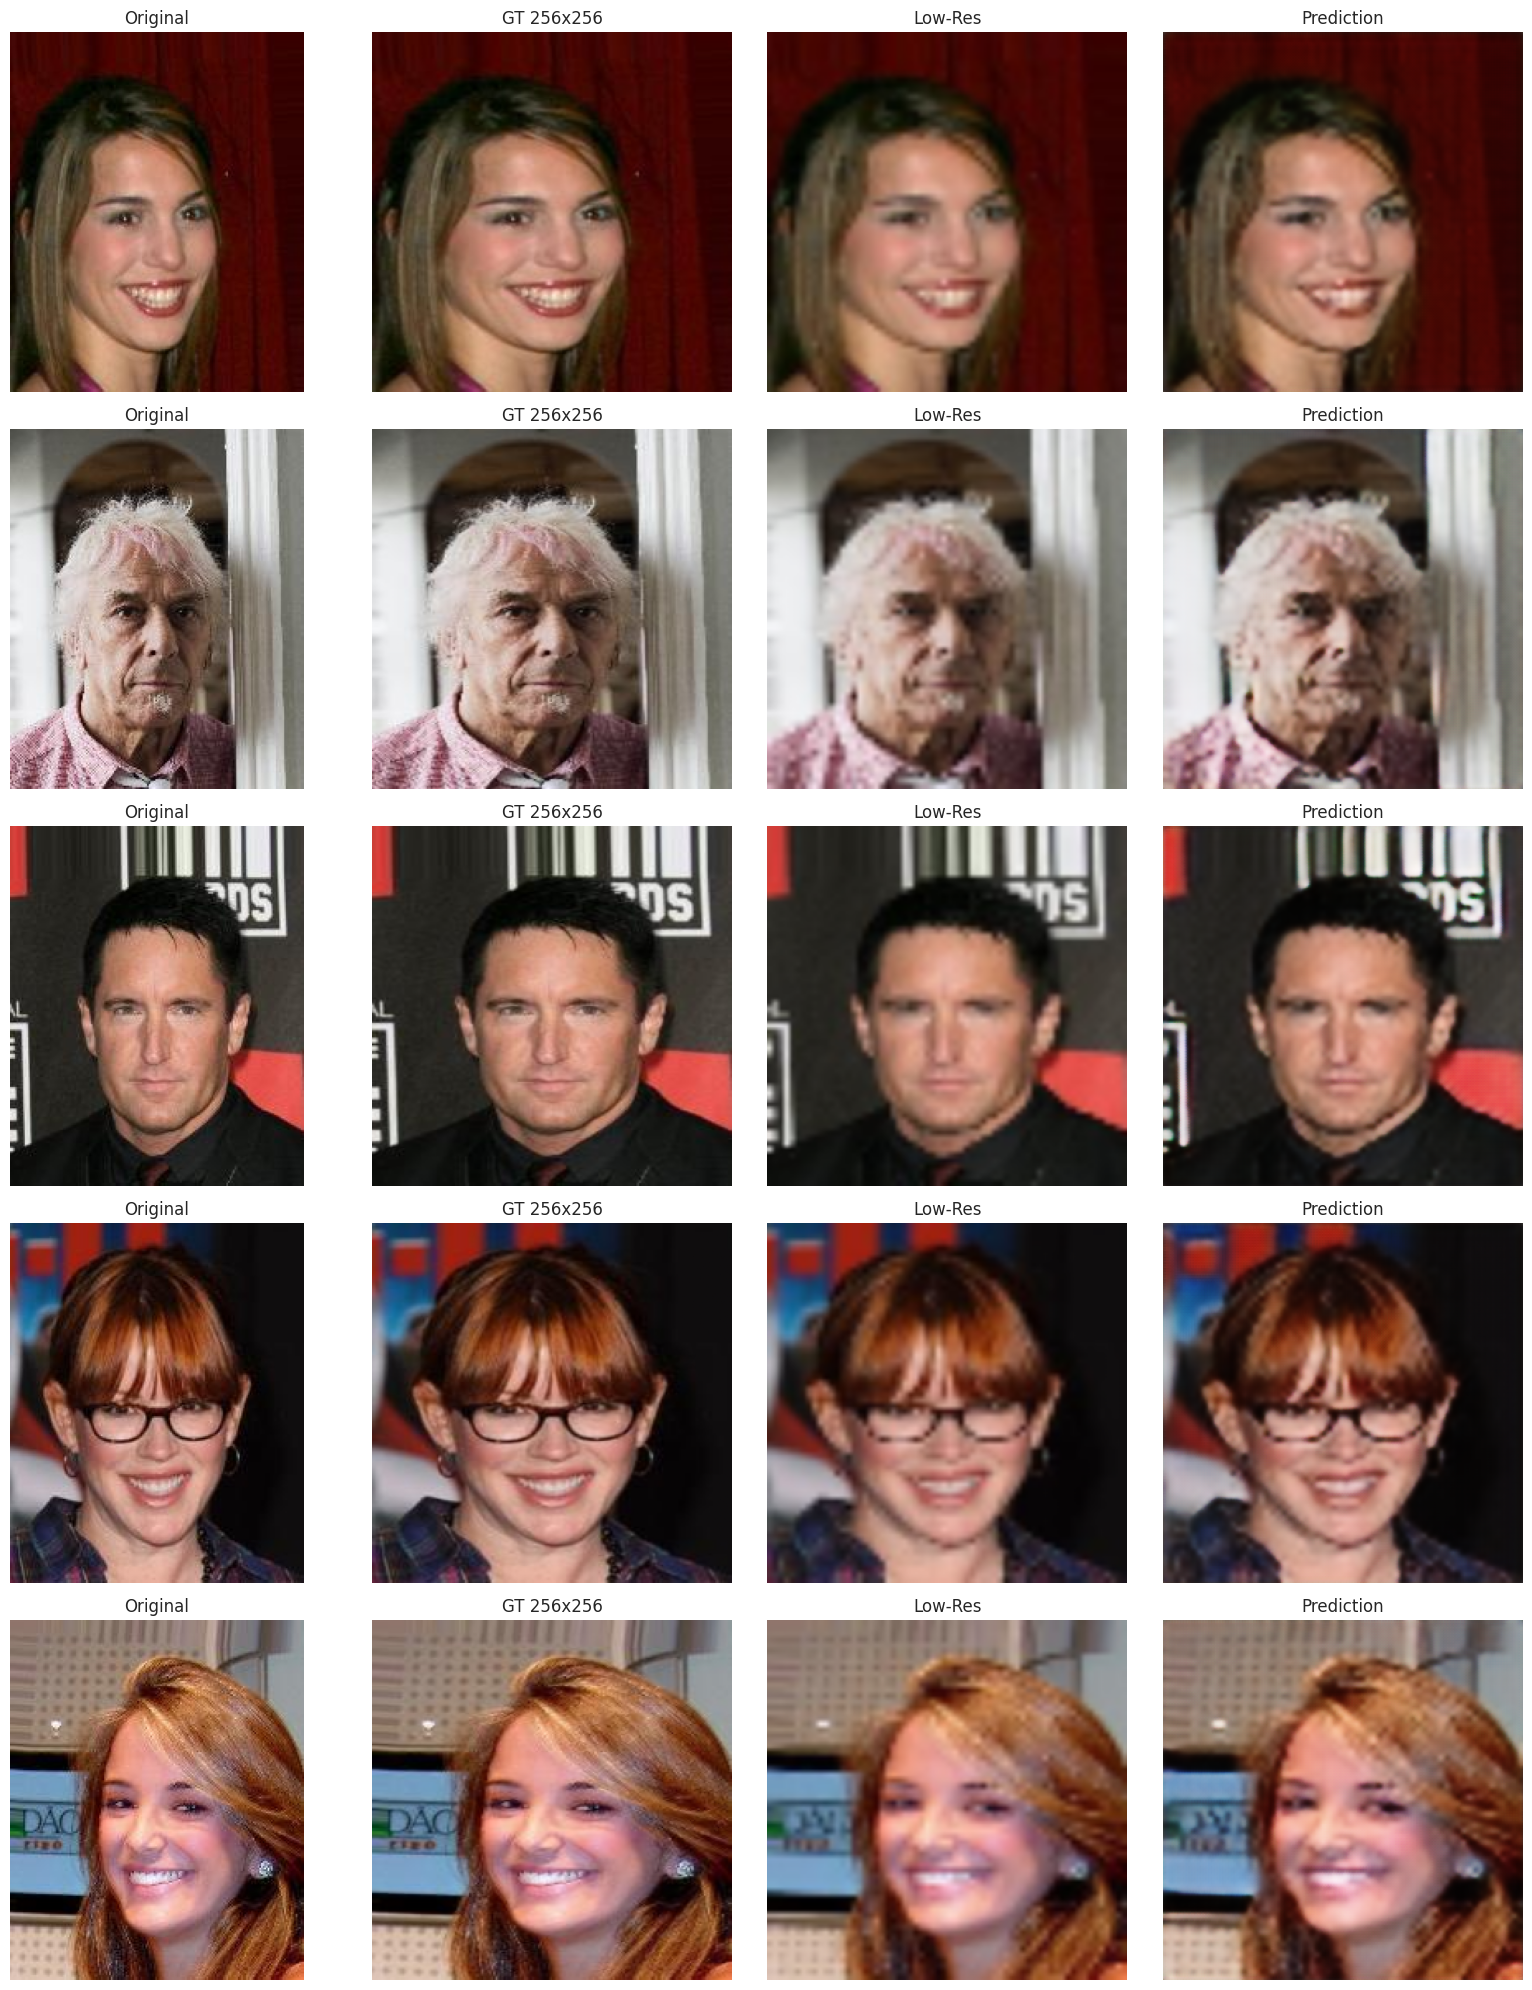

6331/6331 ━━━━━━━━━━━━━━━━━━━━ 951s 150ms/step - loss: 0.0231


In [9]:
import os, cv2 as cv, numpy as np, matplotlib.pyplot as plt, tensorflow as tf

def show_and_save_samples(model, imgs, base_dir, epoch, n=5, save_dir='./epoch_samples'):
    os.makedirs(save_dir, exist_ok=True)
    chosen = np.random.choice(imgs, n, replace=False)
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    if n == 1: axes = np.expand_dims(axes, 0)

    for i, fname in enumerate(chosen):
        # Construct the correct path to the image file
        img_path = os.path.join(base_dir, 'img_align_celeba', 'img_align_celeba', fname)
        rgb = cv.cvtColor(cv.imread(img_path), cv.COLOR_BGR2RGB)
        gt256 = cv.resize(rgb, (256,256)).astype('float32')/255
        img64 = cv.resize(rgb, (64,64)).astype('float32')/255
        pred  = model.predict(np.expand_dims(img64,0), verbose=0)[0]
        lowup = cv.resize((img64*255).astype(np.uint8),(256,256))

        for ax, im, title in zip(axes[i],[rgb,gt256,lowup,pred],
                                 ['Original','GT 256x256','Low-Res','Prediction']):
            ax.imshow(im); ax.set_title(title); ax.axis('off')

    plt.tight_layout(); plt.savefig(f"{save_dir}/epoch_{epoch+1:02d}.png"); plt.show()

# --- Simple Callbacks ---
def on_epoch_end(epoch, logs):
    show_and_save_samples(model, imgs, base_dir, epoch, n=5)
    model.save(f'./checkpoints/model_epoch_{epoch+1:02d}.keras')

show_cb = tf.keras.callbacks.LambdaCallback(on_epoch_end=on_epoch_end)


batch_size = 32
steps_per_epoch = len(imgs)//batch_size
base_dir = path
os.makedirs('./checkpoints', exist_ok=True)

results = model.fit(
    datagen(batch_size=batch_size),
    steps_per_epoch=steps_per_epoch,
    epochs=1,
    callbacks=[show_cb],
    verbose=1)